In [ ]:
# airplane 								
# automobile 										
# bird 										
# cat 										
# deer 										
# dog 										
# frog 										
# horse 										
# ship 										
# truck

In [1]:
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as Optimizers

In [2]:

transform = transforms.Compose([
    transforms.ToTensor(),  # Convert [0,255] → [0,1]
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

train_data = datasets.CIFAR10(root='./data/', train=True, transform=transform, download=True)
test_data = datasets.CIFAR10(root='./data/', train=False, transform=transform, download=True)


In [3]:
# import matplotlib.pyplot as plt

# plt.imshow(raw_train_data.data[2])
# print(raw_train_data.targets[2])

In [4]:
batch_size = 128
train_data_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
test_data_loader = DataLoader(dataset=test_data, batch_size=1, shuffle=False)

In [5]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv_layer1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.batch_norm1 = nn.BatchNorm2d(num_features=8)
        self.relu = nn.ReLU()
        self.max_polling = nn.MaxPool2d(kernel_size=2)
        self.conv_layer2 = nn.Conv2d(in_channels=8, out_channels=32, kernel_size=5, padding=2)
        self.batch_norm2 = nn.BatchNorm2d(num_features=32)
        self.fc_layer1 = nn.Linear(2048, 600)
        self.dropout = nn.Dropout(p = 0.5)
        # self.fc_layer2 = nn.Linear(1000, 500)
        self.output_layer = nn.Linear(600, 10)

    def forward(self, input_data):
        output = self.conv_layer1(input_data)
        output = self.batch_norm1(output)
        output = self.relu(output)
        output = self.max_polling(output)
        output = self.conv_layer2(output)
        output = self.batch_norm2(output)
        output = self.relu(output)
        output = self.max_polling(output)
        output = output.view(-1, 2048)
        output = self.fc_layer1(output)
        output = self.relu(output)
        output = self.dropout(output)
        # output = self.fc_layer2(output)
        # output = self.relu(output)
        # output = self.dropout(output)
        output = self.output_layer(output)
        return output

In [6]:
model = CNNModel()
CUDA = torch.cuda.is_available()
if CUDA:
    model = model.cuda()
loss_func = nn.CrossEntropyLoss()
optimizer = Optimizers.Adam(params=model.parameters(), lr = 0.001)

In [7]:
torch.cuda.is_available()

True

In [8]:
epochs = 50
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for imgs, labels in train_data_loader:
        imgs = imgs.float()
        if CUDA:
            imgs = imgs.cuda()
            labels = labels.cuda()
            
        optimizer.zero_grad()
        preds = model(imgs)
        loss = loss_func(preds, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, max_preds = torch.max(preds, 1)
        correct = (max_preds == labels).sum().item()
        total_correct += correct
        total_samples += imgs.size(0)

    avg_loss = total_loss / len(train_data_loader)
    avg_accuracy = total_correct / total_samples

    print(f"Epoch {epoch + 1}: Training loss: {avg_loss:.4f}, Training accuracy: {avg_accuracy:.4f}")

Epoch 1: Training loss: 1.4982, Training accuracy: 0.4571
Epoch 2: Training loss: 1.2058, Training accuracy: 0.5684
Epoch 3: Training loss: 1.0782, Training accuracy: 0.6170
Epoch 4: Training loss: 0.9958, Training accuracy: 0.6481
Epoch 5: Training loss: 0.9296, Training accuracy: 0.6738
Epoch 6: Training loss: 0.8736, Training accuracy: 0.6915
Epoch 7: Training loss: 0.8269, Training accuracy: 0.7071
Epoch 8: Training loss: 0.7911, Training accuracy: 0.7204
Epoch 9: Training loss: 0.7441, Training accuracy: 0.7369
Epoch 10: Training loss: 0.7089, Training accuracy: 0.7489
Epoch 11: Training loss: 0.6753, Training accuracy: 0.7607
Epoch 12: Training loss: 0.6405, Training accuracy: 0.7727
Epoch 13: Training loss: 0.6114, Training accuracy: 0.7816
Epoch 14: Training loss: 0.5804, Training accuracy: 0.7921
Epoch 15: Training loss: 0.5611, Training accuracy: 0.8006
Epoch 16: Training loss: 0.5293, Training accuracy: 0.8104
Epoch 17: Training loss: 0.5152, Training accuracy: 0.8156
Epoch 

In [9]:
len(train_data_loader)

391

In [13]:
with torch.no_grad():
    model.eval()
    total_loss = 0.0
    accuracy = 0.0

    for imgs, labels in test_data_loader:
        imgs = imgs.float()
        if CUDA:
            imgs = imgs.cuda()
            labels = labels.cuda()

        preds = model(imgs)
        loss = loss_func(preds, labels)
        total_loss += loss.item()

        _, max_preds = torch.max(preds, 1)
        correct = (max_preds == labels).sum().item()
        batch_accuracy = correct / imgs.size(0)
        accuracy += batch_accuracy

    # Average over all batches
    avg_loss = total_loss / len(test_data_loader)
    avg_accuracy = accuracy / len(test_data_loader)

    print(f"Testing loss: {avg_loss:.4f}, Testing accuracy: {avg_accuracy:.4f}")

Testing loss: 1.2677, Testing accuracy: 0.7245


In [16]:
import cv2
import matplotlib.pyplot as plt

torch.Size([1, 3, 32, 32])
tensor([[ -2.1870,  -8.3945,  14.3470, -12.5391, -15.9628,  -3.6970,  -9.8369,
          -6.7151,  -6.2170, -19.5303]], device='cuda:0')


tensor([2], device='cuda:0')

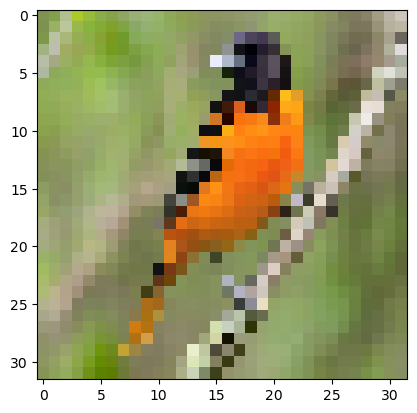

In [38]:
import cv2
import torch
import matplotlib.pyplot as plt

# Load and preprocess
test_img = cv2.imread('data/bird.webp')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img, (32, 32))
plt.imshow(test_img)

# Convert to tensor
test_data = torch.from_numpy(test_img).float()            # (32, 32, 3)
test_data = test_data.permute(2, 0, 1)                   # (3, 32, 32)
test_data = test_data.unsqueeze(0)                        # (1, 3, 32, 32)

# Normalize if training used normalization
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1)
test_data = (test_data / 255.0 - mean) / std

print(test_data.shape)  # should print: torch.Size([1, 3, 32, 32])

with torch.no_grad():
    model.eval()
    if CUDA:
        test_data = test_data.cuda()
    predict = model(test_data)
    _, result = torch.max(predict, 1)\
    
print(predict)
result

torch.Size([1, 3, 32, 32])
tensor([[ -0.5823, -10.2178,  12.7302, -14.9478, -15.7279,  -8.8985,  -8.2666,
         -22.4589,  -9.5956,  -8.2304]], device='cuda:0')


tensor([2], device='cuda:0')

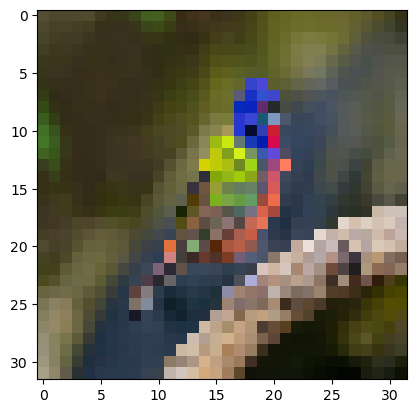

In [39]:
import cv2
import torch
import matplotlib.pyplot as plt

# Load and preprocess
test_img = cv2.imread('data/bird2.jpeg')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img, (32, 32))
plt.imshow(test_img)

# Convert to tensor
test_data = torch.from_numpy(test_img).float()            # (32, 32, 3)
test_data = test_data.permute(2, 0, 1)                   # (3, 32, 32)
test_data = test_data.unsqueeze(0)                        # (1, 3, 32, 32)

# Normalize if training used normalization
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1)
test_data = (test_data / 255.0 - mean) / std

print(test_data.shape)  # should print: torch.Size([1, 3, 32, 32])

with torch.no_grad():
    model.eval()
    if CUDA:
        test_data = test_data.cuda()
    predict = model(test_data)
    _, result = torch.max(predict, 1)

print(predict)
result


torch.Size([1, 3, 32, 32])
tensor([[  1.0672,  -9.6190,  -0.3974,  -9.6472,  -0.0442,  -6.3451, -10.7784,
           1.8760,  -4.0616,  -4.1581]], device='cuda:0')


tensor([7], device='cuda:0')

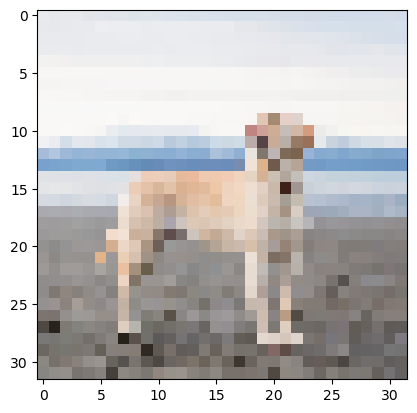

In [40]:
import cv2
import torch
import matplotlib.pyplot as plt

# Load and preprocess
test_img = cv2.imread('data/dog.avif')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img, (32, 32))
plt.imshow(test_img)

# Convert to tensor
test_data = torch.from_numpy(test_img).float()            # (32, 32, 3)
test_data = test_data.permute(2, 0, 1)                   # (3, 32, 32)
test_data = test_data.unsqueeze(0)                        # (1, 3, 32, 32)

# Normalize if training used normalization
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1)
test_data = (test_data / 255.0 - mean) / std

print(test_data.shape)  # should print: torch.Size([1, 3, 32, 32])

with torch.no_grad():
    model.eval()
    if CUDA:
        test_data = test_data.cuda()
    predict = model(test_data)
    _, result = torch.max(predict, 1)

print(predict)
result


torch.Size([1, 3, 32, 32])
tensor([[-15.9154, -22.3707,   3.3211,  -1.0599,  -2.5683,  -3.2496,   4.0586,
          -5.6384, -16.8625, -11.4777]], device='cuda:0')


tensor([6], device='cuda:0')

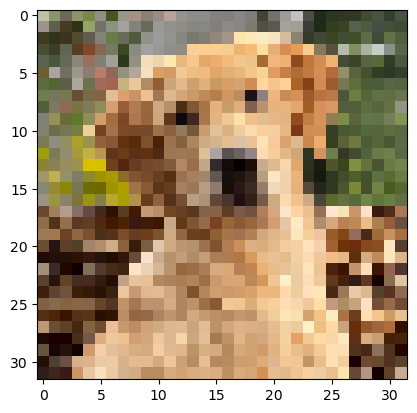

In [41]:
import cv2
import torch
import matplotlib.pyplot as plt

# Load and preprocess
test_img = cv2.imread('data/dog2.webp')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img, (32, 32))
plt.imshow(test_img)

# Convert to tensor
test_data = torch.from_numpy(test_img).float()            # (32, 32, 3)
test_data = test_data.permute(2, 0, 1)                   # (3, 32, 32)
test_data = test_data.unsqueeze(0)                        # (1, 3, 32, 32)

# Normalize if training used normalization
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1)
test_data = (test_data / 255.0 - mean) / std

print(test_data.shape)  # should print: torch.Size([1, 3, 32, 32])

with torch.no_grad():
    model.eval()
    if CUDA:
        test_data = test_data.cuda()
    predict = model(test_data)
    _, result = torch.max(predict, 1)

print(predict)
result


torch.Size([1, 3, 32, 32])
tensor([[-34.7216,  -9.2859, -18.2329, -10.9405, -47.6136, -20.5637,  31.7963,
         -57.6899,  -5.1218, -21.3609]], device='cuda:0')


tensor([6], device='cuda:0')

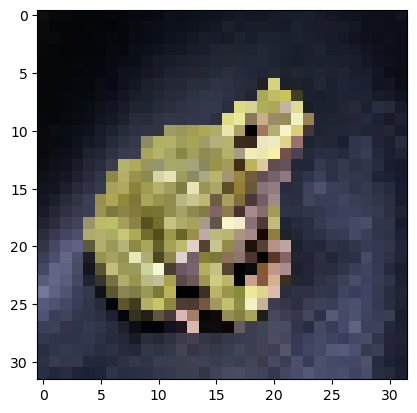

In [42]:
import cv2
import torch
import matplotlib.pyplot as plt

# Load and preprocess
test_img = cv2.imread('data/frog.jpg')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img, (32, 32))
plt.imshow(test_img)

# Convert to tensor
test_data = torch.from_numpy(test_img).float()            # (32, 32, 3)
test_data = test_data.permute(2, 0, 1)                   # (3, 32, 32)
test_data = test_data.unsqueeze(0)                        # (1, 3, 32, 32)

# Normalize if training used normalization
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1)
test_data = (test_data / 255.0 - mean) / std

print(test_data.shape)  # should print: torch.Size([1, 3, 32, 32])

with torch.no_grad():
    model.eval()
    if CUDA:
        test_data = test_data.cuda()
    predict = model(test_data)
    _, result = torch.max(predict, 1)

print(predict)
result


torch.Size([1, 3, 32, 32])
tensor([[  7.4642,  -1.9300,  -8.3003,  -9.4541, -19.9297, -16.8201,  -9.4857,
         -17.9001,   3.4298,  -6.5379]], device='cuda:0')


tensor([0], device='cuda:0')

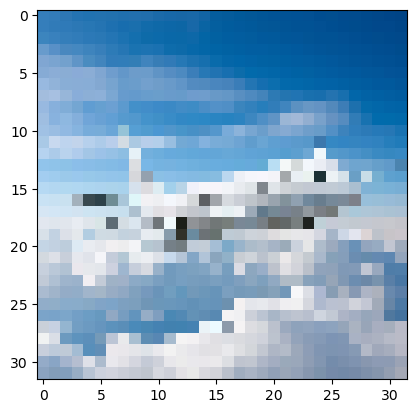

In [43]:
import cv2
import torch
import matplotlib.pyplot as plt

# Load and preprocess
test_img = cv2.imread('data/airplane.webp')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img, (32, 32))
plt.imshow(test_img)

# Convert to tensor
test_data = torch.from_numpy(test_img).float()            # (32, 32, 3)
test_data = test_data.permute(2, 0, 1)                   # (3, 32, 32)
test_data = test_data.unsqueeze(0)                        # (1, 3, 32, 32)

# Normalize if training used normalization
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1)
test_data = (test_data / 255.0 - mean) / std

print(test_data.shape)  # should print: torch.Size([1, 3, 32, 32])

with torch.no_grad():
    model.eval()
    if CUDA:
        test_data = test_data.cuda()
    predict = model(test_data)
    _, result = torch.max(predict, 1)

print(predict)
result


torch.Size([1, 3, 32, 32])
tensor([[  3.3723,   2.3758,  -7.4003, -20.8162, -14.5883, -23.7968, -17.2975,
         -21.6114,   8.9132,  -5.7032]], device='cuda:0')


tensor([8], device='cuda:0')

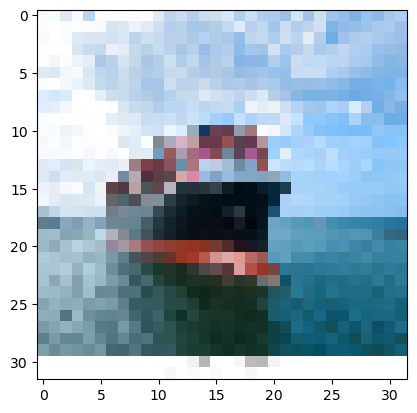

In [44]:
import cv2
import torch
import matplotlib.pyplot as plt

# Load and preprocess
test_img = cv2.imread('data/ship.webp')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img, (32, 32))
plt.imshow(test_img)

# Convert to tensor
test_data = torch.from_numpy(test_img).float()            # (32, 32, 3)
test_data = test_data.permute(2, 0, 1)                   # (3, 32, 32)
test_data = test_data.unsqueeze(0)                        # (1, 3, 32, 32)

# Normalize if training used normalization
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1)
test_data = (test_data / 255.0 - mean) / std

print(test_data.shape)  # should print: torch.Size([1, 3, 32, 32])

with torch.no_grad():
    model.eval()
    if CUDA:
        test_data = test_data.cuda()
    predict = model(test_data)
    _, result = torch.max(predict, 1)

print(predict)
result


torch.Size([1, 3, 32, 32])
tensor([[-16.9068, -15.8052,   4.8385, -10.3327, -27.6164, -35.0659,  14.8610,
         -37.6516,  -0.9482,  -9.7032]], device='cuda:0')


tensor([6], device='cuda:0')

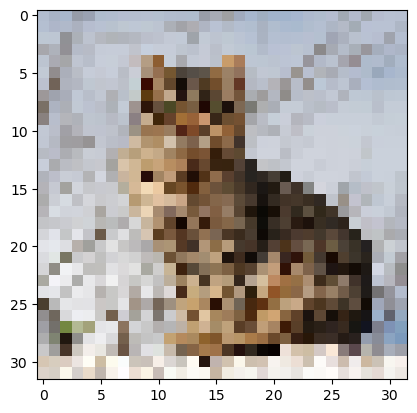

In [45]:
import cv2
import torch
import matplotlib.pyplot as plt

# Load and preprocess
test_img = cv2.imread('data/cat.jpg')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img, (32, 32))
plt.imshow(test_img)

# Convert to tensor
test_data = torch.from_numpy(test_img).float()            # (32, 32, 3)
test_data = test_data.permute(2, 0, 1)                   # (3, 32, 32)
test_data = test_data.unsqueeze(0)                        # (1, 3, 32, 32)

# Normalize if training used normalization
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1)
test_data = (test_data / 255.0 - mean) / std

print(test_data.shape)  # should print: torch.Size([1, 3, 32, 32])

with torch.no_grad():
    model.eval()
    if CUDA:
        test_data = test_data.cuda()
    predict = model(test_data)
    _, result = torch.max(predict, 1)

print(predict)
result


torch.Size([1, 3, 32, 32])
tensor([[-25.9722, -42.7318,   3.9257,  -3.7185, -31.7399, -43.0885,  26.7796,
         -55.2752,  -5.4651, -10.8598]], device='cuda:0')


tensor([6], device='cuda:0')

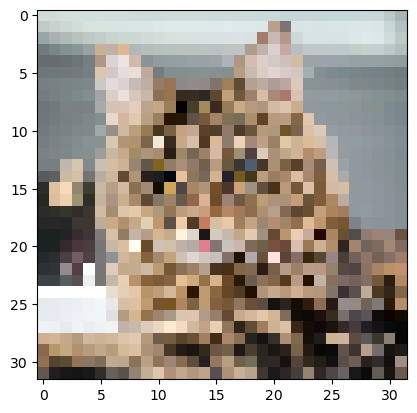

In [46]:
import cv2
import torch
import matplotlib.pyplot as plt

# Load and preprocess
test_img = cv2.imread('data/cat2.jpg')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img, (32, 32))
plt.imshow(test_img)

# Convert to tensor
test_data = torch.from_numpy(test_img).float()            # (32, 32, 3)
test_data = test_data.permute(2, 0, 1)                   # (3, 32, 32)
test_data = test_data.unsqueeze(0)                        # (1, 3, 32, 32)

# Normalize if training used normalization
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1)
test_data = (test_data / 255.0 - mean) / std

print(test_data.shape)  # should print: torch.Size([1, 3, 32, 32])

with torch.no_grad():
    model.eval()
    if CUDA:
        test_data = test_data.cuda()
    predict = model(test_data)
    _, result = torch.max(predict, 1)

print(predict)
result


torch.Size([1, 3, 32, 32])
tensor([[  2.5667, -17.2205,   4.4480, -22.5291,  -8.2301, -19.4129,  -4.0847,
          14.6997, -36.4323,  -9.1514]], device='cuda:0')


tensor([7], device='cuda:0')

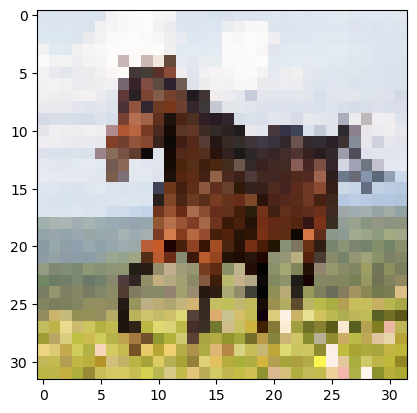

In [47]:
import cv2
import torch
import matplotlib.pyplot as plt

# Load and preprocess
test_img = cv2.imread('data/horse.png')
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img, (32, 32))
plt.imshow(test_img)

# Convert to tensor
test_data = torch.from_numpy(test_img).float()            # (32, 32, 3)
test_data = test_data.permute(2, 0, 1)                   # (3, 32, 32)
test_data = test_data.unsqueeze(0)                        # (1, 3, 32, 32)

# Normalize if training used normalization
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1)
test_data = (test_data / 255.0 - mean) / std

print(test_data.shape)  # should print: torch.Size([1, 3, 32, 32])

with torch.no_grad():
    model.eval()
    if CUDA:
        test_data = test_data.cuda()
    predict = model(test_data)
    _, result = torch.max(predict, 1)

print(predict)
result
